# Erdos-Renyi G(n, p) and Steinerberger Curvature

This notebook cell imports utilities, builds an Erdos-Renyi graph with fixed seed, and computes Steinerberger curvature.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import scipy.sparse as sp
from facialgen.curvature import steinerberger_curvature

n = 500
p = 0.5
seed = 1

rng = np.random.default_rng(seed)
upper = np.triu(rng.random((n, n)) < p, k=1)
A = sp.csr_matrix((upper | upper.T).astype(np.float64))

x = steinerberger_curvature(A, use_lcc=False, solver="lstsq", rhs_scale=n)

print(f"A shape: {A.shape}, nnz: {A.nnz}")
print(f"curvature shape: {x.shape}")
print(f"first 10 values: {x[:10]}")
print(f"mean={x.mean():.6f}, std={x.std():.6f}, min={x.min():.6f}, max={x.max():.6f}")

A shape: (500, 500), nnz: 125012
curvature shape: (500,)
first 10 values: [ 2.60882093  0.82409826  7.46821009 -7.47233583  2.64729498  3.89745276
  1.31175921  3.93205991  3.78043104  2.11214217]
mean=0.666371, std=5.990996, min=-17.338616, max=21.002403


In [ ]:
# # Multi-p experiment: compare curvature-sign rotations vs random rotations
# import pandas as pd
# from IPython.display import display
# from facialgen.curvature import steinerberger_curvature, largest_connected_component
# from facialgen.rotation_systems import facial_walks_from_curvature_signs, random_rotation_system, enumerate_facial_walks_from_rotation

# n_fixed = 500
# graph_seed = 1
# p_values = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
# num_samples = 30

# rows = []

# for p_i, p_val in enumerate(p_values):
#     # Fixed graph per p value (deterministic with graph_seed + offset).
#     rng_graph = np.random.default_rng(graph_seed + p_i)
#     upper = np.triu(rng_graph.random((n_fixed, n_fixed)) < p_val, k=1)
#     A_full = sp.csr_matrix((upper | upper.T).astype(np.float64))

#     # Extract LCC explicitly to know its size for rhs_scale.
#     A_lcc, nodes_lcc = largest_connected_component(A_full)
#     n_lcc = A_lcc.shape[0]

#     # Compute curvature on LCC with rhs_scale=n_lcc (solving D*x = n*1)
#     x_lcc = steinerberger_curvature(
#         A_lcc,
#         use_lcc=False,
#         solver="lstsq",
#         rhs_scale=float(n_lcc),
#     )

#     sign_rng = np.random.default_rng(10_000 + p_i)
#     rand_rot_rng = np.random.default_rng(20_000 + p_i)

#     counts_curv = np.empty(num_samples, dtype=int)
#     counts_rand = np.empty(num_samples, dtype=int)

#     for j in range(num_samples):
#         signs = sign_rng.choice(np.array([-1, 1], dtype=int), size=n_lcc, replace=True)
#         faces_curv = facial_walks_from_curvature_signs(A_lcc, x_lcc, signs)
#         counts_curv[j] = len(faces_curv)

#         rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
#         faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
#         counts_rand[j] = len(faces_rand)

#     rows.append({
#         "p": p_val,
#         "n_lcc": int(n_lcc),
#         "curv_mean": float(counts_curv.mean()),
#         "rand_mean": float(counts_rand.mean()),
#     })

In [ ]:
# df_results = pd.DataFrame(rows)
# df_results = df_results[["p", "n_lcc", "curv_mean", "rand_mean"]]

# # Paper-friendly column names (no underscores).
# table = df_results.rename(
#     columns={
#         "p": "Edge Probability p",
#         "n_lcc": "LCC Size n",
#         "curv_mean": "Mean Faces (Curvature +/-)",
#         "rand_mean": "Mean Faces (Random Rotation)",
#     }
# )

# styled = (
#     table.style
#     .format({
#         "Edge Probability p": "{:.2f}",
#         "Mean Faces (Curvature +/-)": "{:.2f}",
#         "Mean Faces (Random Rotation)": "{:.2f}",
#     })
#     .set_caption("Mean Facial Walk Counts: Curvature-Based Rotation vs Random Rotation")
#     .set_properties(**{"text-align": "center"})
#     .set_table_styles([
#         {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
#         {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "bold")]},
#     ])
# )

# display(styled)

,Edge Probability p,LCC Size n,Mean Faces (Curvature +/-),Mean Faces (Random Rotation)
0,0.05,500,29.40,7.40
1,0.10,500,101.80,9.13
2,0.20,500,393.40,9.07
3,0.30,500,900.67,10.47
4,0.40,500,1606.53,10.67
5,0.50,500,2749.20,11.87


# Curvatures face count compared against n

n sweep:   0%|          | 0/10 [00:00<?, ?it/s]

methods @ n=80:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=120:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=160:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=220:   0%|          | 0/4 [00:00<?, ?it/s]

...

methods @ n=500:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=700:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=850:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=1000:   0%|          | 0/4 [00:00<?, ?it/s]

Method,n,Lin-Lu-Yau (approx),Ollivier-Ricci (approx),Random Rotation,Resistance,Steinerberger
0,80,79.60,52.70,6.60,76.00,85.70
1,120,160.30,67.60,8.10,154.10,159.90
2,160,269.20,108.70,8.90,303.20,285.80
3,220,437.60,86.60,10.10,518.20,500.30
4,300,511.70,81.90,9.40,997.00,974.50
5,400,480.90,56.50,9.80,1745.80,1749.60
6,500,358.20,35.80,10.80,2660.20,2638.70
7,700,195.60,20.40,11.60,5263.30,5265.90
8,850,178.70,17.40,11.20,7683.50,7717.50
9,1000,138.80,17.30,12.00,10667.60,10644.70


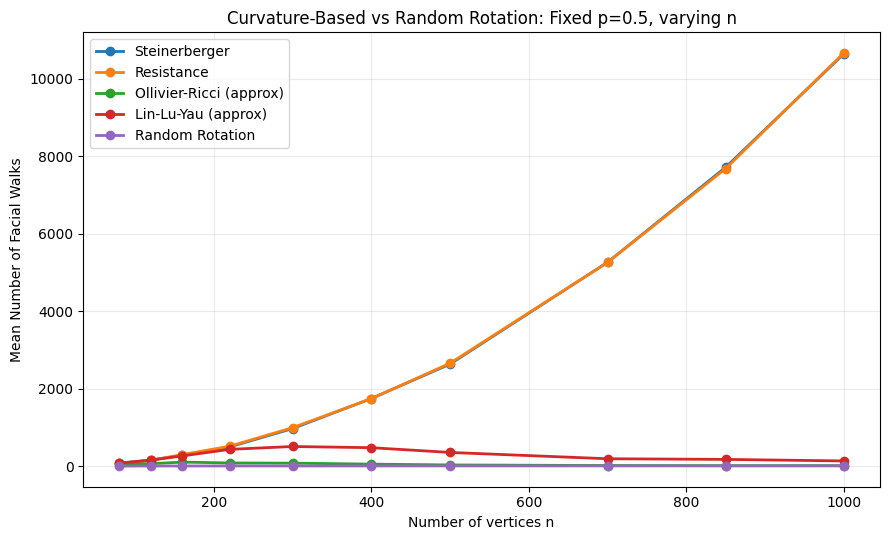

In [2]:
# Multi-n curvature comparison at fixed p=0.5 (with progress bars)
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import importlib
from IPython.display import display
from tqdm.auto import tqdm

import facialgen
import facialgen.curvature as curvature
import facialgen.rotation_systems as rotation_systems

importlib.invalidate_caches()
importlib.reload(facialgen)
importlib.reload(curvature)
importlib.reload(rotation_systems)

from facialgen.curvature import (
    largest_connected_component,
    steinerberger_curvature,
    resistance_curvature,
    ollivier_ricci_curvature,
    lin_lu_yau_curvature,
    )
from facialgen.rotation_systems import (
    facial_walks_from_curvature_signs,
    random_rotation_system,
    enumerate_facial_walks_from_rotation,
    )

p_fixed = 0.5
graph_seed = 1
n_values = [80, 120, 160, 220, 300, 400, 500, 700, 850, 1000]
num_samples = 20

rows = []

for i_n, n_val in enumerate(tqdm(n_values, desc="n sweep")):
    # One graph per n at fixed p; all methods below use this same graph.
    rng_graph = np.random.default_rng(graph_seed + i_n)
    upper = np.triu(rng_graph.random((n_val, n_val)) < p_fixed, k=1)
    A_full = sp.csr_matrix((upper | upper.T).astype(np.float64))

    A_lcc, nodes_lcc = largest_connected_component(A_full)
    n_lcc = A_lcc.shape[0]

    curvatures = {
        "Steinerberger": steinerberger_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Resistance": resistance_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Ollivier-Ricci (approx)": ollivier_ricci_curvature(
            A_lcc, alpha=0.5, max_neighbors=16, edge_sample_size=800, seed=11 + i_n
        ),
        "Lin-Lu-Yau (approx)": lin_lu_yau_curvature(
            A_lcc, alpha_near_one=0.99, max_neighbors=16, edge_sample_size=800, seed=11 + i_n
        ),
    }

    # Use the same sampled sign assignments for all curvature methods for fairness.
    sign_rng = np.random.default_rng(30_000 + i_n)
    sign_samples = sign_rng.choice(
        np.array([-1, 1], dtype=int),
        size=(num_samples, n_lcc),
        replace=True,
    )

    for method_name, curvature_vec in tqdm(
        curvatures.items(), desc=f"methods @ n={n_val}", leave=False
    ):
        counts = np.empty(num_samples, dtype=int)
        for i in range(num_samples):
            faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
            counts[i] = len(faces)

        rows.append({
            "n": int(n_lcc),
            "Method": method_name,
            "Mean Faces": float(counts.mean()),
        })

    # Random-rotation baseline on the same graph.
    rand_rot_rng = np.random.default_rng(40_000 + i_n)
    counts_rand = np.empty(num_samples, dtype=int)
    for i in range(num_samples):
        rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
        faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
        counts_rand[i] = len(faces_rand)

    rows.append({
        "n": int(n_lcc),
        "Method": "Random Rotation",
        "Mean Faces": float(counts_rand.mean()),
    })

results_long = pd.DataFrame(rows)
results_table = results_long.pivot(
    index="n",
    columns="Method",
    values="Mean Faces",
).reset_index()

# Display a clean table first.
display(
    results_table.style
    .format({c: "{:.2f}" for c in results_table.columns if c != "n"})
    .set_caption("Mean Facial Walk Counts by Method (fixed p=0.5, varying n)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "bold")]},
    ])
)

# And one comparison plot with all methods.
plt.figure(figsize=(9, 5.5))
for method_name in [
    "Steinerberger",
    "Resistance",
    "Ollivier-Ricci (approx)",
    "Lin-Lu-Yau (approx)",
    "Random Rotation",
]:
    plt.plot(
        results_table["n"],
        results_table[method_name],
        marker="o",
        linewidth=2,
        label=method_name,
    )

plt.xlabel("Number of vertices n")
plt.ylabel("Mean Number of Facial Walks")
plt.title("Curvature-Based vs Random Rotation: Fixed p=0.5, varying n")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Curvatures approaches calculated on CoraML dataset

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from facialgen.data import load_graph_dataset_sparse
from facialgen.curvature import (
    largest_connected_component,
    steinerberger_curvature,
    resistance_curvature,
    ollivier_ricci_curvature,
    lin_lu_yau_curvature,
)
from facialgen.rotation_systems import (
    facial_walks_from_curvature_signs,
    random_rotation_system,
    enumerate_facial_walks_from_rotation,
)

A_full, X, y = load_graph_dataset_sparse("coraml", data_dir="data")
A_lcc, nodes_lcc = largest_connected_component(A_full)
n_lcc = A_lcc.shape[0]

curvatures = {
    "Steinerberger": steinerberger_curvature(
        A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
    ),
    "Resistance": resistance_curvature(
        A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
    ),
    "Ollivier-Ricci (approx)": ollivier_ricci_curvature(
        A_lcc, alpha=0.5, max_neighbors=16, edge_sample_size=1500, seed=101
    ),
    "Lin-Lu-Yau (approx)": lin_lu_yau_curvature(
        A_lcc,
        alpha_near_one=0.99,
        max_neighbors=16,
        edge_sample_size=1500,
        seed=101,
    ),
}

num_samples = 20
sign_rng = np.random.default_rng(2026)
sign_samples = sign_rng.choice(
    np.array([-1, 1], dtype=int),
    size=(num_samples, n_lcc),
    replace=True,
)

rows = []

for method_name, curvature_vec in curvatures.items():
    counts = np.empty(num_samples, dtype=int)
    for i in range(num_samples):
        faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
        counts[i] = len(faces)

    rows.append({
        "Method": method_name,
        "Mean Faces": float(counts.mean()),
        "Std Faces": float(counts.std()),
        "Min Faces": int(counts.min()),
        "Max Faces": int(counts.max()),
    })

rand_rot_rng = np.random.default_rng(404)
counts_rand = np.empty(num_samples, dtype=int)
for i in range(num_samples):
    rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
    faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
    counts_rand[i] = len(faces_rand)

rows.append({
    "Method": "Random Rotation",
    "Mean Faces": float(counts_rand.mean()),
    "Std Faces": float(counts_rand.std()),
    "Min Faces": int(counts_rand.min()),
    "Max Faces": int(counts_rand.max()),
})

results = pd.DataFrame(rows).sort_values("Method").reset_index(drop=True)
display(
    results.style
    .format({"Mean Faces": "{:.2f}", "Std Faces": "{:.2f}"})
    .set_caption("CoraML facial-walk counts: curvature-based +/- vs random rotation")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "bold")]},
    ])
)


,Method,Mean Faces,Std Faces,Min Faces,Max Faces
0,Lin-Lu-Yau (approx),149.00,10.60,125,169
1,Ollivier-Ricci (approx),146.80,11.38,127,167
2,Random Rotation,90.00,10.54,71,123
3,Resistance,199.50,13.71,179,223
4,Steinerberger,182.40,11.03,153,199


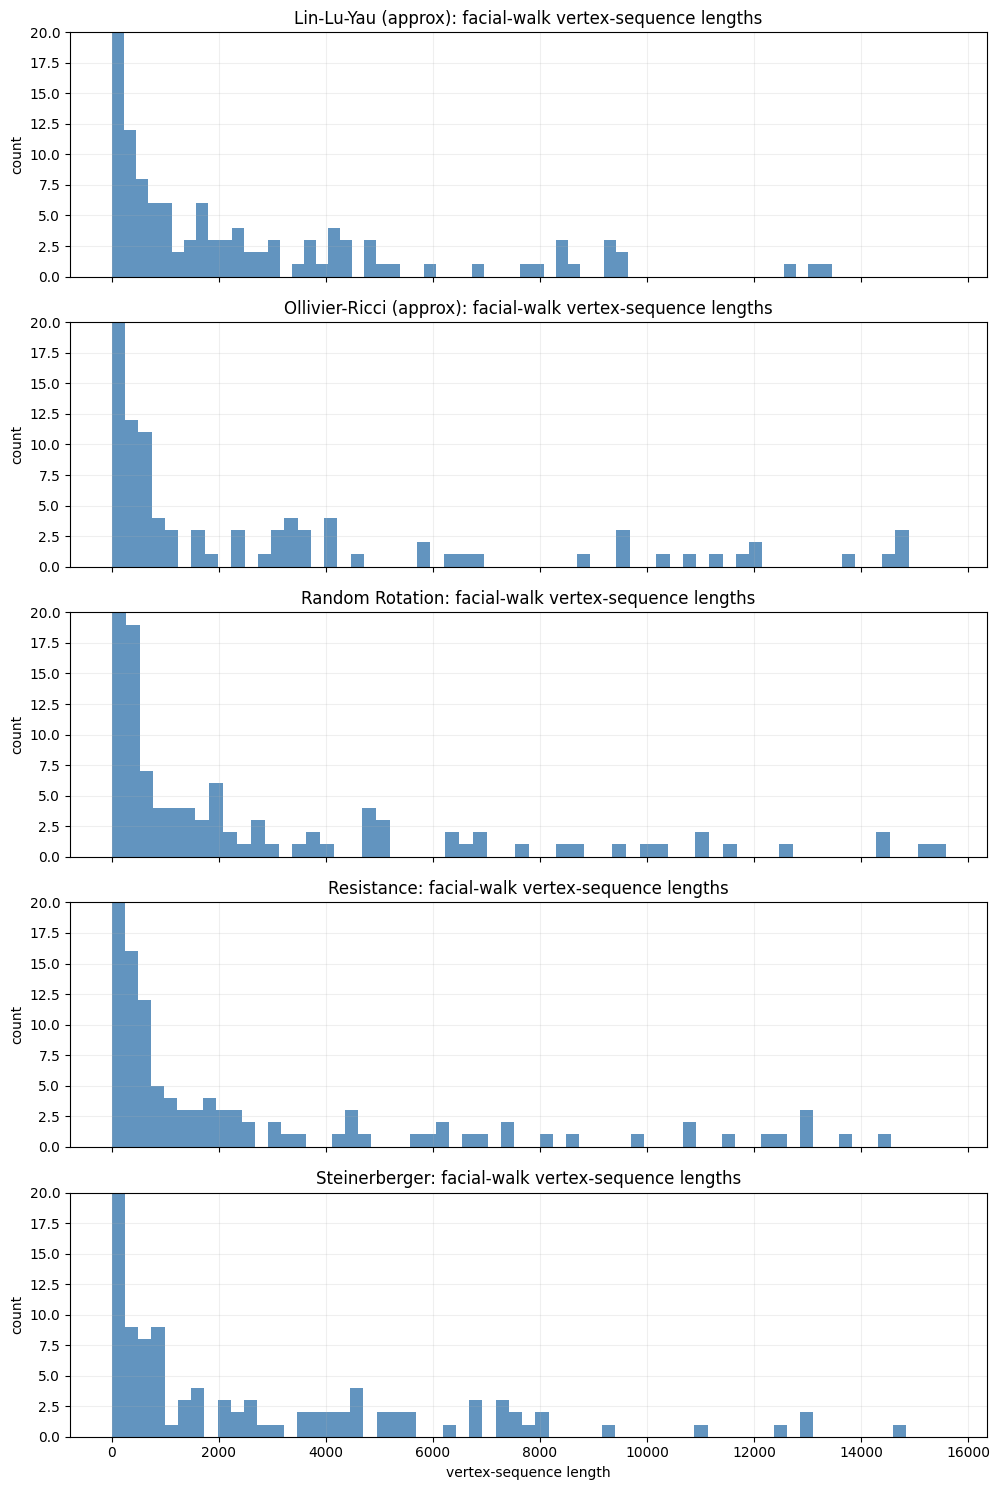

,Method,Mean Length,Median Length,Max Length,Num Faces Sampled
0,Lin-Lu-Yau (approx),108.127517,5.0,13451,2980
1,Ollivier-Ricci (approx),109.732970,5.0,14887,2936
2,Random Rotation,178.355556,5.0,15579,1800
3,Resistance,81.010025,5.0,14554,3990
4,Steinerberger,88.510965,5.0,14841,3648


In [7]:
import matplotlib.pyplot as plt
from facialgen.rotation_systems import dart_face_to_vertex_sequence

length_samples = {}

for method_name, curvature_vec in curvatures.items():
    method_lengths = []
    for i in range(num_samples):
        faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
        method_lengths.extend(len(dart_face_to_vertex_sequence(face)) for face in faces)
    length_samples[method_name] = np.asarray(method_lengths, dtype=int)

rand_rot_rng = np.random.default_rng(404)
rand_lengths = []
for i in range(num_samples):
    rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
    faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
    rand_lengths.extend(len(dart_face_to_vertex_sequence(face)) for face in faces_rand)
length_samples['Random Rotation'] = np.asarray(rand_lengths, dtype=int)

fig, axes = plt.subplots(
    len(length_samples),
    1,
    figsize=(10, 3.0 * len(length_samples)),
    sharex=True,
)
axes = np.atleast_1d(axes)

for ax, (method_name, lengths) in zip(axes, sorted(length_samples.items())):
    ax.hist(lengths, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(f"{method_name}: facial-walk vertex-sequence lengths")
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)
    ax.set_ylim(0, 20)

axes[-1].set_xlabel("vertex-sequence length")
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {
        "Method": method_name,
        "Mean Length": float(lengths.mean()),
        "Median Length": float(np.median(lengths)),
        "Max Length": int(lengths.max()),
        "Num Faces Sampled": int(lengths.size),
    }
    for method_name, lengths in sorted(length_samples.items())
]))
